# Лабораторна робота №3  
## Візуалізація даних

**Мета роботи:**  
Ознайомитися з методами візуалізації даних за допомогою бібліотек Python та побудувати різні типи графіків для аналізу датасету.

**Джерело датасету:**  https://archive.ics.uci.edu/dataset/2/adult

In [1]:
# Імпорт бібліотек для аналізу та візуалізації даних

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Завантажуємо датасет

In [2]:
# Список назв колонок датасету

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race",
    "sex", "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

# Завантаження датасету з файлу adult.data

df = pd.read_csv("adult.data", names=columns)

In [3]:
# Виведення перших 5 рядків датасету

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Аналізуємо структури даних

Перевіряємо структуру датасету та типи даних у колонках.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


## 3. Data Cleaning

У датасеті пропущені значення позначені символом `?` замінемо ці значення на NaN для подальшого аналізу.

In [6]:
df = df.replace("?", np.nan)

# Перевіряємо кількість пропущених значень

df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

### 4. Видалення пропущених значень

Для спрощення аналізу видалимо рядки з пропущеними значеннями.

In [7]:
df = df.dropna()

# Перевіряємо новий розмір датасету

df.shape

(32561, 15)

## 5. Побудова Scatter Plot

Побудуємо графік залежності між віком людини (age) та кількістю робочих годин на тиждень (hours-per-week).

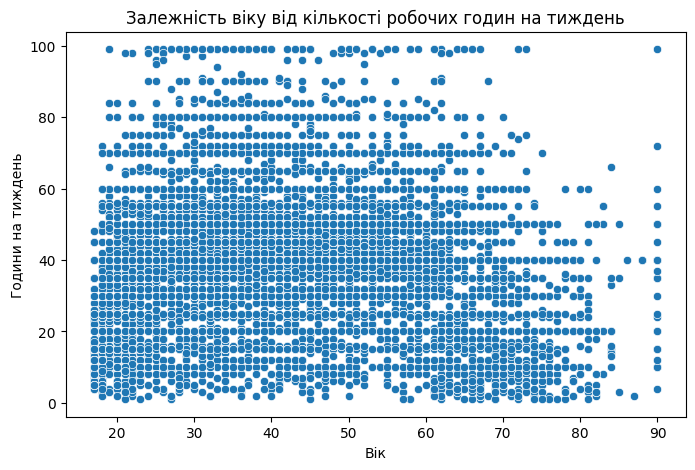

In [9]:
# Побудова scatter plot для age та hours-per-week

plt.figure(figsize=(8,5))

sns.scatterplot(x=df["age"], y=df["hours-per-week"])

plt.title("Залежність віку від кількості робочих годин на тиждень")
plt.xlabel("Вік")
plt.ylabel("Години на тиждень")

plt.show()

## 6. Побудова Line Plot

Побудуємо лінійний графік для відображення залежності між віком та кількістю робочих годин.

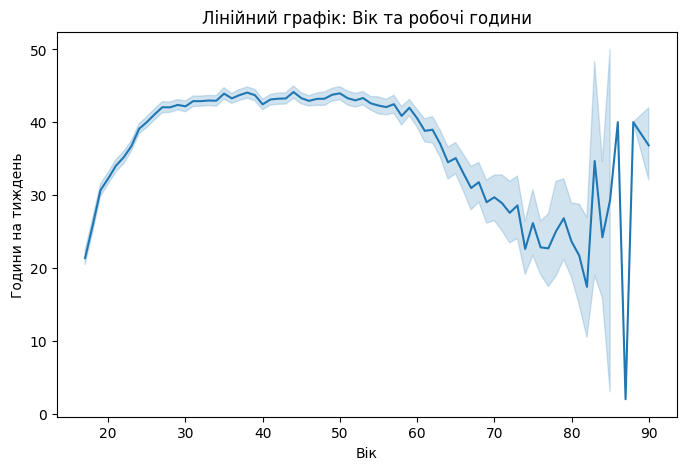

In [10]:
# Побудова line plot

plt.figure(figsize=(8,5))

sns.lineplot(x=df["age"], y=df["hours-per-week"])

plt.title("Лінійний графік: Вік та робочі години")
plt.xlabel("Вік")
plt.ylabel("Години на тиждень")

plt.show()

## 7. Побудова гістограми

Побудуємо гістограму для атрибуту age.
Гістограма покаже розподіл людей за віком у 5 діапазонах.

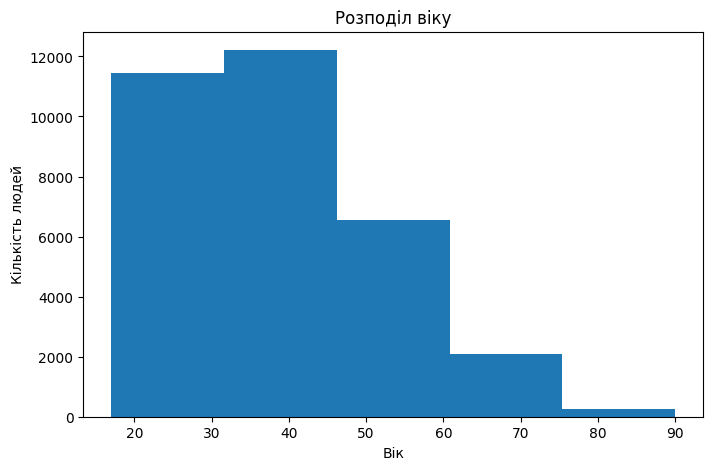

In [11]:
# Побудова гістограми для віку

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=5)

plt.title("Розподіл віку")
plt.xlabel("Вік")
plt.ylabel("Кількість людей")

plt.show()

## 8. Побудова Boxplot

Boxplot дозволяє побачити розподіл значень та можливі викиди.

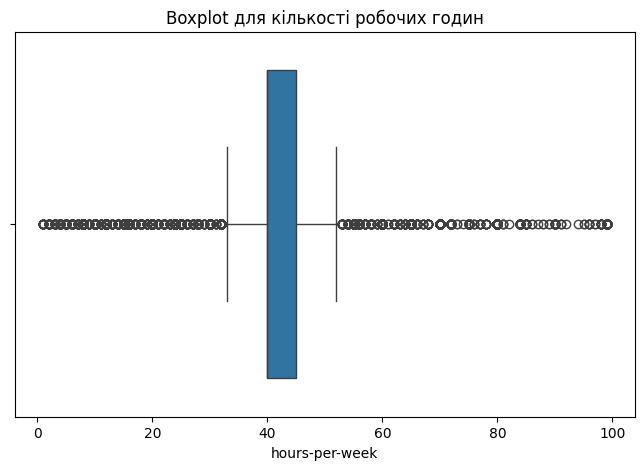

In [12]:
# Побудова boxplot для hours-per-week

plt.figure(figsize=(8,5))

sns.boxplot(x=df["hours-per-week"])

plt.title("Boxplot для кількості робочих годин")

plt.show()

## 9. Побудова Bar Plot

Побудуємо графік розподілу людей за статтю.

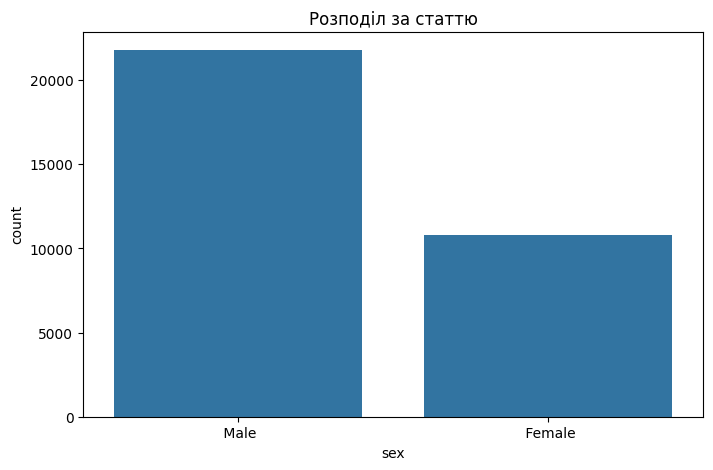

In [13]:
# Побудова bar plot для статі

plt.figure(figsize=(8,5))

sns.countplot(x=df["sex"])

plt.title("Розподіл за статтю")

plt.show()

## 10. Побудова Heatmap

За допомогою Heatmap дивимось кореляцію між числовими атрибутами датасету.

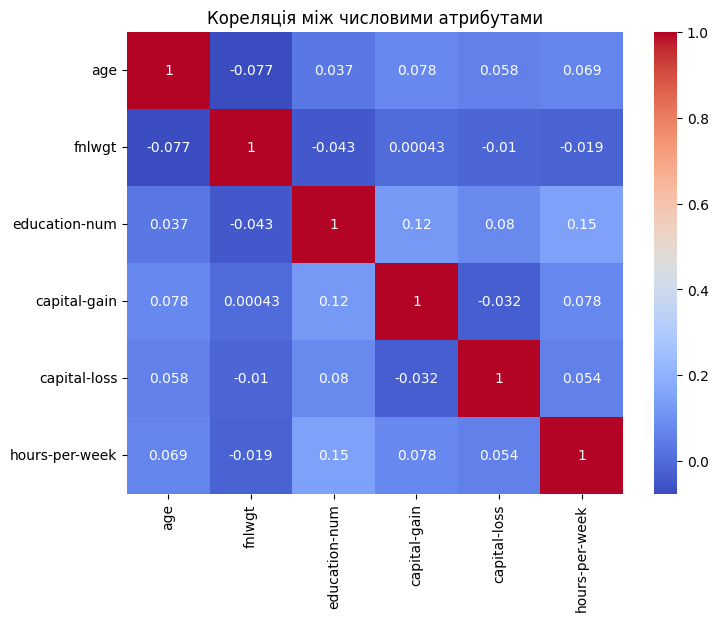

In [14]:
# Обчислення кореляції

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Кореляція між числовими атрибутами")

plt.show()